# Registered Nurse Workforce Dynamics Across Canadian Jurisdictions, 2018–2024

**A reproducible analysis of registered-nurse workforce inflow, outflow, and international recruitment using Canadian Institute for Health Information (CIHI) data.**

This portfolio project examines how RN workforce dynamics differed across Canadian jurisdictions between 2018 and 2024. It emphasizes transparent temporal alignment, explicit missing-data handling, reproducible validation, and evidence-based interpretation.


## Research questions

1. How did the composition of RN inflow differ across jurisdictions?
2. How did current-year inflow compare with preceding-year outflow after accounting for workforce size?
3. How did the internationally educated share of RN inflow change from 2018 to 2024?


## Data source and analytical scope

- **Source:** CIHI, *Nursing in Canada, 2016–2025: Data Tables*, Table 4a and Definitions sheet.
- **Population:** Registered nurses in Canadian provinces and territories represented in Table 4a.
- **Reporting period:** 2018–2024.
- **Baseline:** 2017 is retained only to calculate the longitudinal measures reported for 2018.
- **Missing data:** Suppressed and non-numeric source values remain missing (`NaN`) and are never silently replaced with zero.
- **Comparability:** Figures use the eight jurisdictions with all seven analysis years and every field required by the visualizations.

The workbook is downloaded automatically from CIHI when it is not already available in the local `data/` directory.


In [1]:
from pathlib import Path
from urllib.error import HTTPError, URLError
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


DATA_URL = (
    "https://www.cihi.ca/sites/default/files/document/"
    "nursing-in-canada-2016-2025-data-tables-en.xlsx"
)
DATA_FILENAME = "nursing-in-canada-2016-2025-data-tables-en.xlsx"
ANALYSIS_YEARS = list(range(2018, 2025))
BASELINE_YEAR = 2017
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PROVINCES = [
    "Newfoundland and Labrador",
    "Prince Edward Island",
    "Nova Scotia",
    "New Brunswick",
    "Quebec",
    "Ontario",
    "Manitoba",
    "Saskatchewan",
    "Alberta",
    "British Columbia",
]
TERRITORIES = ["Yukon", "Northwest Territories/Nunavut"]
JURISDICTIONS = PROVINCES + TERRITORIES

EXPECTED_COMPLETE_SERIES = {
    "British Columbia",
    "New Brunswick",
    "Newfoundland and Labrador",
    "Nova Scotia",
    "Ontario",
    "Quebec",
    "Saskatchewan",
    "Yukon",
}


def get_workbook() -> Path:
    """Return a local CIHI workbook path, downloading it when necessary."""
    data_dir = Path("data")
    data_dir.mkdir(parents=True, exist_ok=True)
    workbook_path = data_dir / DATA_FILENAME

    if not workbook_path.exists():
        print(f"Downloading CIHI workbook to {workbook_path} ...")
        request = Request(
            DATA_URL,
            headers={"User-Agent": "Mozilla/5.0 (RN workforce portfolio analysis)"},
        )
        try:
            with urlopen(request, timeout=60) as response:
                workbook_path.write_bytes(response.read())
        except (HTTPError, URLError) as error:
            raise RuntimeError(
                "The CIHI workbook could not be downloaded automatically. "
                f"Download {DATA_FILENAME} from {DATA_URL} and place it in "
                f"{data_dir.resolve()}."
            ) from error

    return workbook_path


def save_figure(figure: plt.Figure, filename: str) -> None:
    """Save a publication-ready PNG while retaining inline notebook display."""
    output_path = OUTPUT_DIR / filename
    figure.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )
    print(f"Saved chart: {output_path}")


## 1. Load and reshape the CIHI data

Table 4a is converted from CIHI's wide reporting layout into a jurisdiction-year analytical table. The registered-nurse records are selected, suppression marks are converted to missing values, and the source categories are pivoted into consistently named fields.


In [2]:
workbook_path = get_workbook()

# The Definitions sheet is loaded to keep the analysis tied to CIHI's source
# terminology. Table 4a supplies the observations used below.
definitions = pd.read_excel(workbook_path, sheet_name="Definitions")
raw_4a = pd.read_excel(workbook_path, sheet_name="Table 4a", skiprows=1)

raw_4a.columns.values[:4] = ["nurse_type", "jurisdiction", "category", "group"]
raw_4a["nurse_type"] = raw_4a["nurse_type"].ffill()
raw_4a["jurisdiction"] = raw_4a["jurisdiction"].ffill()

year_columns = [
    column
    for column in raw_4a.columns
    if str(column).strip().isdigit()
    and BASELINE_YEAR <= int(str(column).strip()) <= max(ANALYSIS_YEARS)
]

expected_years = set(range(BASELINE_YEAR, max(ANALYSIS_YEARS) + 1))
found_years = {int(str(column).strip()) for column in year_columns}
if found_years != expected_years:
    raise ValueError(
        f"Expected workbook years {sorted(expected_years)}, found {sorted(found_years)}."
    )

rn_long = raw_4a.loc[
    raw_4a["nurse_type"].eq("Registered nurses"),
    ["jurisdiction", "category", "group", *year_columns],
].melt(
    id_vars=["jurisdiction", "category", "group"],
    value_vars=year_columns,
    var_name="year",
    value_name="value_raw",
)

# CIHI suppression marks and other non-numeric entries become NaN. They are
# never replaced with zero.
rn_long["value"] = pd.to_numeric(
    rn_long["value_raw"]
    .astype("string")
    .str.replace(",", "", regex=False)
    .str.strip(),
    errors="coerce",
)
rn_long["year"] = rn_long["year"].astype(int)

rn_pivot = rn_long.pivot_table(
    index=["jurisdiction", "year"],
    columns=["category", "group"],
    values="value",
    aggfunc="first",
).reset_index()


def flatten_column(column: object) -> str:
    """Convert a scalar or MultiIndex column label to snake case."""
    parts = column if isinstance(column, tuple) else (column,)
    clean_parts = [
        str(part).strip().lower().replace(" ", "_")
        for part in parts
        if str(part).strip() and str(part).strip().lower() != "nan"
    ]
    return "_".join(clean_parts).strip("_")


rn_pivot.columns = [flatten_column(column) for column in rn_pivot.columns]
rn_pivot = rn_pivot.rename(
    columns={
        "workforce_total": "workforce",
        "inflow_canadian_educated": "inflow_domestic",
        "inflow_internationally_educated": "inflow_intl",
        "inflow_grad_location_not_stated": "inflow_not_stated",
        "outflow_total": "outflow",
        "renewal_total": "renewal",
    }
)

required_columns = {
    "jurisdiction",
    "year",
    "workforce",
    "inflow_total",
    "inflow_domestic",
    "inflow_intl",
    "inflow_not_stated",
    "outflow",
    "renewal",
}
missing_columns = required_columns.difference(rn_pivot.columns)
if missing_columns:
    raise KeyError(f"Expected CIHI fields were not found: {sorted(missing_columns)}")


## 2. Construct the longitudinal measures

For jurisdiction $j$ and year $t$:

$$\text{Workforce change}_{j,t}=\text{Workforce}_{j,t}-\text{Workforce}_{j,t-1}$$

$$\text{Net flow}_{j,t}=\text{Inflow}_{j,t}-\text{Outflow}_{j,t-1}$$

Current-year inflow and preceding-year outflow are divided by the preceding-year workforce and expressed per 1,000 nurses. Calculations are retained only when the earlier observation is from the immediately preceding calendar year.

The decomposition discrepancy is the difference between observed workforce change and the simplified net-flow measure. It is retained as a diagnostic rather than assumed to be zero.


In [3]:
rn_base = rn_pivot.loc[rn_pivot["jurisdiction"].isin(JURISDICTIONS)].copy()
rn_base["geo_type"] = np.where(
    rn_base["jurisdiction"].isin(PROVINCES), "Province", "Territory"
)
rn_base = rn_base.sort_values(["jurisdiction", "year"]).reset_index(drop=True)

grouped = rn_base.groupby("jurisdiction", sort=False)
rn_base["prev_year"] = grouped["year"].shift(1)
rn_base["prev_workforce"] = grouped["workforce"].shift(1)
rn_base["prev_outflow"] = grouped["outflow"].shift(1)
rn_base["consecutive_year"] = rn_base["year"].sub(rn_base["prev_year"]).eq(1)

rn_base["workforce_change"] = (
    rn_base["workforce"] - rn_base["prev_workforce"]
).where(rn_base["consecutive_year"])
rn_base["net_flow"] = (
    rn_base["inflow_total"] - rn_base["prev_outflow"]
).where(rn_base["consecutive_year"])
rn_base["decomp_discrepancy"] = (
    rn_base["workforce_change"] - rn_base["net_flow"]
)

valid_denominator = rn_base["prev_workforce"].gt(0) & rn_base["consecutive_year"]
rn_base["workforce_growth_pct"] = (
    rn_base["workforce_change"] / rn_base["prev_workforce"] * 100
).where(valid_denominator)
rn_base["inflow_per_1k"] = (
    rn_base["inflow_total"] / rn_base["prev_workforce"] * 1_000
).where(valid_denominator)
rn_base["outflow_churn_per_1k"] = (
    rn_base["prev_outflow"] / rn_base["prev_workforce"] * 1_000
).where(valid_denominator)
rn_base["net_flow_per_1k"] = (
    rn_base["net_flow"] / rn_base["prev_workforce"] * 1_000
).where(valid_denominator)
rn_base["intl_share_pct"] = (
    rn_base["inflow_intl"] / rn_base["inflow_total"] * 100
).where(rn_base["inflow_total"].gt(0))

rn_final = rn_base.loc[rn_base["year"].isin(ANALYSIS_YEARS)].copy()


## 3. Validate the analytical data

The validation checks establish that:

- jurisdiction-year observations are unique;
- inflow components reconcile to total inflow whenever every component is reported;
- longitudinal calculations use consecutive calendar years;
- the complete-series set contains the expected eight jurisdictions; and
- the workforce-change decomposition is explicitly inspected.

Rows with missing inflow components are labelled **Not Verifiable**, not treated as valid zero-valued components.


In [4]:
component_columns = ["inflow_domestic", "inflow_intl", "inflow_not_stated"]
reconciliation_columns = [*component_columns, "inflow_total"]

rn_final["inflow_validity"] = "Not Verifiable"
verifiable = rn_final[reconciliation_columns].notna().all(axis=1)
reconciles = np.isclose(
    rn_final.loc[verifiable, component_columns].sum(axis=1),
    rn_final.loc[verifiable, "inflow_total"],
)
rn_final.loc[verifiable, "inflow_validity"] = np.where(
    reconciles, "Valid", "Mismatch"
)

duplicate_count = int(
    rn_final.duplicated(subset=["jurisdiction", "year"], keep=False).sum()
)
if duplicate_count:
    raise ValueError(f"Found {duplicate_count} duplicate jurisdiction-year rows.")

inflow_status_counts = (
    rn_final["inflow_validity"]
    .value_counts()
    .reindex(["Valid", "Not Verifiable", "Mismatch"], fill_value=0)
)
if inflow_status_counts["Mismatch"]:
    raise ValueError(
        f"Found {inflow_status_counts['Mismatch']} inflow reconciliation mismatches."
    )

core_metrics = ["workforce", "inflow_total", "renewal", "outflow"]
figure_metrics = [
    *component_columns,
    "intl_share_pct",
    "inflow_per_1k",
    "outflow_churn_per_1k",
]


def has_complete_series(group: pd.DataFrame) -> bool:
    """Require all seven analysis years and all fields used in the figures."""
    window = group.loc[group["year"].isin(ANALYSIS_YEARS)].set_index("year")
    if set(window.index) != set(ANALYSIS_YEARS) or not window.index.is_unique:
        return False
    required = [*core_metrics, *figure_metrics]
    return bool(
        window[required].notna().all().all()
        and window["consecutive_year"].all()
        and window["inflow_validity"].eq("Valid").all()
    )


full_sets = sorted(
    jurisdiction
    for jurisdiction, group in rn_final.groupby("jurisdiction")
    if has_complete_series(group)
)

if set(full_sets) != EXPECTED_COMPLETE_SERIES:
    raise ValueError(
        "The complete-series jurisdictions changed. "
        f"Expected {sorted(EXPECTED_COMPLETE_SERIES)}; found {full_sets}."
    )

continuity_issues = int((~rn_final["consecutive_year"]).sum())
decomp_summary = rn_final["decomp_discrepancy"].abs().agg(["mean", "max"])

print("VALIDATION SUMMARY")
print(f"Duplicate jurisdiction-year rows: {duplicate_count}")
print(f"Rows without an immediately preceding calendar year: {continuity_issues}")
print("Inflow component reconciliation:")
print(inflow_status_counts.to_string())
print(
    "Absolute decomposition discrepancy "
    f"(mean / max): {decomp_summary['mean']:.2f} / {decomp_summary['max']:.2f}"
)
print(f"Complete-series jurisdictions ({len(full_sets)}): {', '.join(full_sets)}")

# The discrepancy is reported as a diagnostic, not treated as an error: annual
# workforce change need not equal the simplified inflow-minus-prior-outflow
# identity because of revisions and other movements captured in the source.


VALIDATION SUMMARY
Duplicate jurisdiction-year rows: 0
Rows without an immediately preceding calendar year: 1
Inflow component reconciliation:
inflow_validity
Valid             72
Not Verifiable     2
Mismatch           0
Absolute decomposition discrepancy (mean / max): 0.00 / 0.00
Complete-series jurisdictions (8): British Columbia, New Brunswick, Newfoundland and Labrador, Nova Scotia, Ontario, Quebec, Saskatchewan, Yukon


## 4. Create the figure-level summary tables

The following tables supply the exact values used by the three figures. Aggregation occurs only after the complete-series restriction has been applied.


In [5]:
plot_df = rn_final.loc[rn_final["jurisdiction"].isin(full_sets)].copy()

inflow_totals = plot_df.groupby("jurisdiction")[reconciliation_columns].sum(
    min_count=len(ANALYSIS_YEARS)
)
inflow_composition = (
    inflow_totals[component_columns]
    .div(inflow_totals["inflow_total"], axis=0)
    .mul(100)
    .sort_values("inflow_intl", ascending=False)
)
inflow_composition.columns = [
    "Canadian educated",
    "Internationally educated",
    "Grad location not stated",
]

growth_summary = (
    plot_df.groupby("jurisdiction")
    .agg(
        avg_annual_growth_pct=("workforce_growth_pct", "mean"),
        inflow_per_1k=("inflow_per_1k", "mean"),
        outflow_churn_per_1k=("outflow_churn_per_1k", "mean"),
        net_flow_per_1k=("net_flow_per_1k", "mean"),
    )
    .sort_values("avg_annual_growth_pct", ascending=False)
)

share_table = plot_df.pivot(
    index="jurisdiction", columns="year", values="intl_share_pct"
)
share_change = pd.DataFrame(
    {
        "2018 share (%)": share_table[2018],
        "2024 share (%)": share_table[2024],
    }
)
share_change["change (percentage points)"] = (
    share_change["2024 share (%)"] - share_change["2018 share (%)"]
)
share_change = share_change.sort_values(
    "change (percentage points)", ascending=False
)

print("\nAGGREGATE INFLOW COMPOSITION, 2018–2024 (%)")
print(inflow_composition.round(2).to_string())
print("\nAVERAGE ANNUAL WORKFORCE DYNAMICS, 2018–2024")
print(growth_summary.round(2).to_string())
print("\nCHANGE IN INTERNATIONALLY EDUCATED SHARE, 2018–2024")
print(share_change.round(2).to_string())



AGGREGATE INFLOW COMPOSITION, 2018–2024 (%)
                           Canadian educated  Internationally educated  Grad location not stated
jurisdiction                                                                                    
Ontario                                79.38                      20.6                      0.02
Nova Scotia                            82.01                     17.69                       0.3
Quebec                                 84.27                     15.73                       0.0
British Columbia                       86.57                     12.31                      1.12
Newfoundland and Labrador              88.21                     11.79                       0.0
New Brunswick                          89.85                      9.21                      0.94
Saskatchewan                           88.63                      8.92                      2.45
Yukon                                  92.56                      5.46            

## Figure 1 — RN inflow composition

This 100% stacked bar chart compares the aggregate composition of reported RN inflow from 2018 through 2024. Jurisdictions are ordered by the internationally educated share.


Saved chart: outputs/figure_1_inflow_composition.png


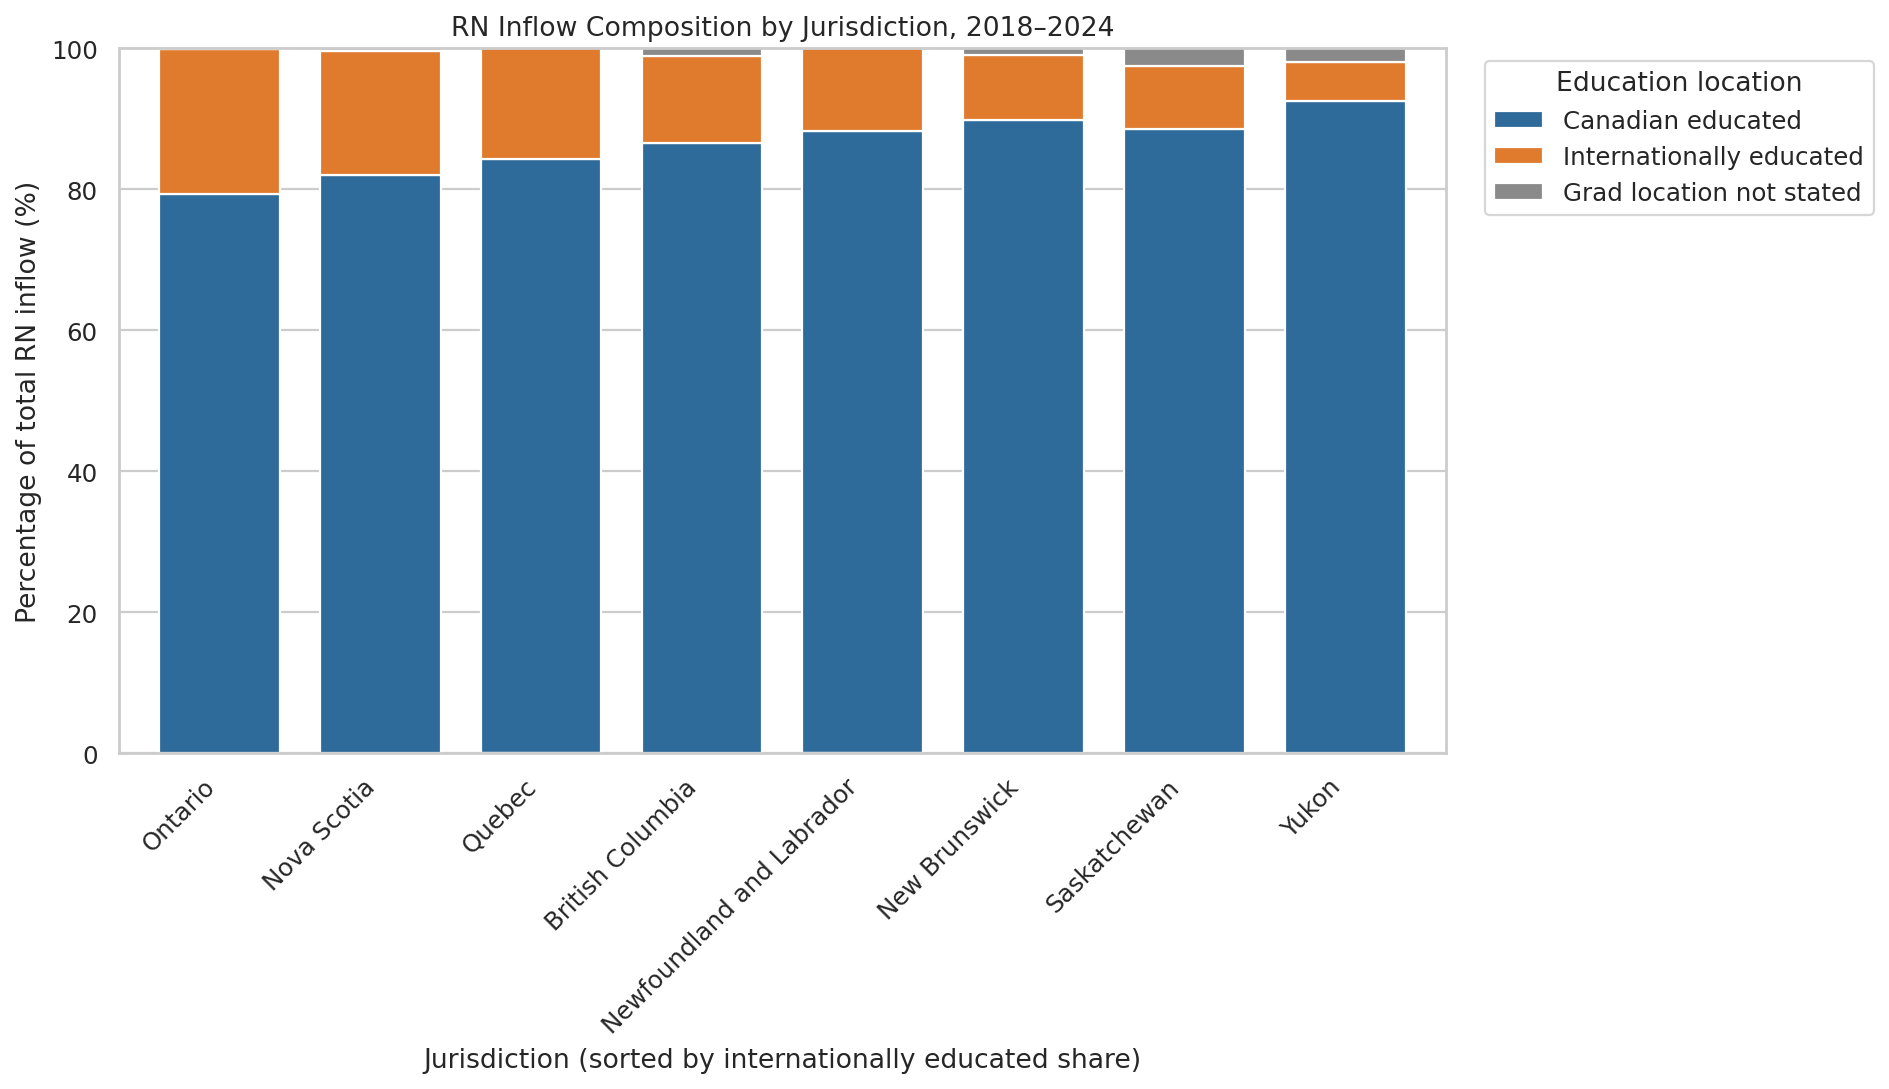

In [6]:
sns.set_theme(style="whitegrid")
figure_1, axis_1 = plt.subplots(figsize=(12, 7))
inflow_composition.plot(
    kind="bar",
    stacked=True,
    width=0.75,
    color=["#2F6B9A", "#E07A2D", "#8A8A8A"],
    ax=axis_1,
)
axis_1.set(
    title="RN Inflow Composition by Jurisdiction, 2018–2024",
    xlabel="Jurisdiction (sorted by internationally educated share)",
    ylabel="Percentage of total RN inflow (%)",
    ylim=(0, 100),
)
axis_1.legend(title="Education location", bbox_to_anchor=(1.02, 1), loc="upper left")
axis_1.tick_params(axis="x", rotation=45)
for label in axis_1.get_xticklabels():
    label.set_horizontalalignment("right")
figure_1.tight_layout()
save_figure(figure_1, "figure_1_inflow_composition.png")
plt.show()


**Interpretation.** Ontario had the largest aggregate internationally educated share of RN inflow among the complete-series jurisdictions (20.60%), followed by Nova Scotia (17.69%) and Quebec (15.73%). Yukon had the smallest share (5.46%). These figures describe inflow composition across the full period; they do not show when within the period the composition changed.


## Figure 2 — Inflow intensity versus preceding-year outflow churn

Each point represents a jurisdiction's average annual inflow and preceding-year outflow, normalized per 1,000 nurses in the preceding-year workforce. The equal-axis design and dashed 45-degree line provide a direct break-even comparison: points above the line had average inflow greater than preceding-year outflow.


Saved chart: outputs/figure_2_inflow_vs_outflow.png


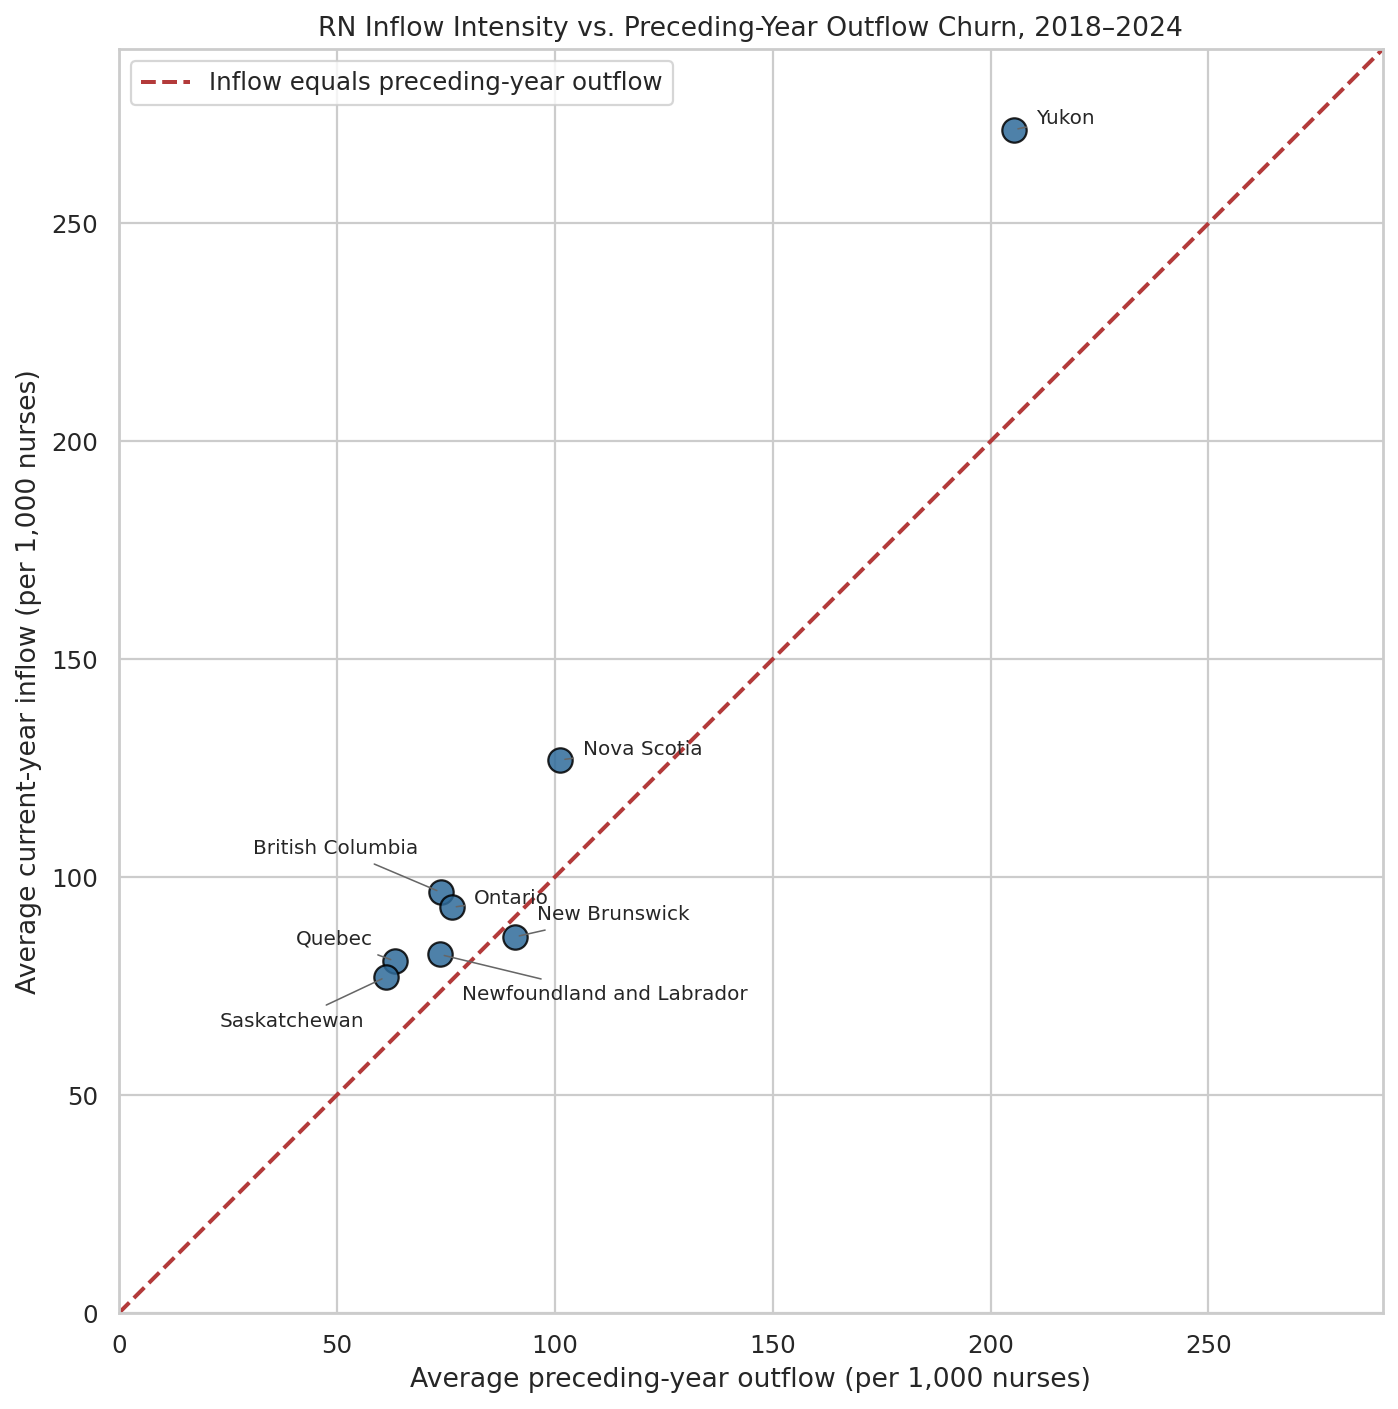

In [7]:
figure_2, axis_2 = plt.subplots(figsize=(9, 9))
axis_2.scatter(
    growth_summary["outflow_churn_per_1k"],
    growth_summary["inflow_per_1k"],
    s=120,
    color="#2F6B9A",
    edgecolor="black",
    alpha=0.85,
)

axis_limit = float(
    np.ceil(
        max(
            growth_summary["outflow_churn_per_1k"].max(),
            growth_summary["inflow_per_1k"].max(),
        )
        / 10
    )
    * 10
    + 10
)
axis_2.plot(
    [0, axis_limit],
    [0, axis_limit],
    color="#B33A3A",
    linestyle="--",
    linewidth=1.8,
    label="Inflow equals preceding-year outflow",
)
label_offsets = {
    "British Columbia": (-10, 20, "right"),
    "Ontario": (10, 4, "left"),
    "New Brunswick": (10, 10, "left"),
    "Newfoundland and Labrador": (10, -18, "left"),
    "Quebec": (-10, 10, "right"),
    "Saskatchewan": (-10, -20, "right"),
    "Nova Scotia": (10, 5, "left"),
    "Yukon": (10, 5, "left"),
}
for jurisdiction, row in growth_summary.iterrows():
    offset_x, offset_y, alignment = label_offsets[jurisdiction]
    axis_2.annotate(
        jurisdiction,
        (row["outflow_churn_per_1k"], row["inflow_per_1k"]),
        xytext=(offset_x, offset_y),
        textcoords="offset points",
        ha=alignment,
        va="center",
        fontsize=9,
        arrowprops={"arrowstyle": "-", "color": "#666666", "linewidth": 0.7},
    )

axis_2.set(
    title="RN Inflow Intensity vs. Preceding-Year Outflow Churn, 2018–2024",
    xlabel="Average preceding-year outflow (per 1,000 nurses)",
    ylabel="Average current-year inflow (per 1,000 nurses)",
    xlim=(0, axis_limit),
    ylim=(0, axis_limit),
)
axis_2.set_aspect("equal", adjustable="box")
axis_2.legend(loc="upper left")
figure_2.tight_layout()
save_figure(figure_2, "figure_2_inflow_vs_outflow.png")
plt.show()


**Interpretation.** Seven of the eight complete-series jurisdictions were above the break-even line. New Brunswick was slightly below it, averaging 86.30 inflows versus 90.88 preceding-year outflows per 1,000 nurses. Yukon had the highest overall movement intensity and the largest average positive gap, while Nova Scotia had the next-largest positive gap.


## Figure 3 — Internationally educated share of annual RN inflow

The small multiples show annual change rather than the period-wide composition displayed in Figure 1. All panels use a common y-axis so their levels and changes remain directly comparable.


Saved chart: outputs/figure_3_international_share_trends.png


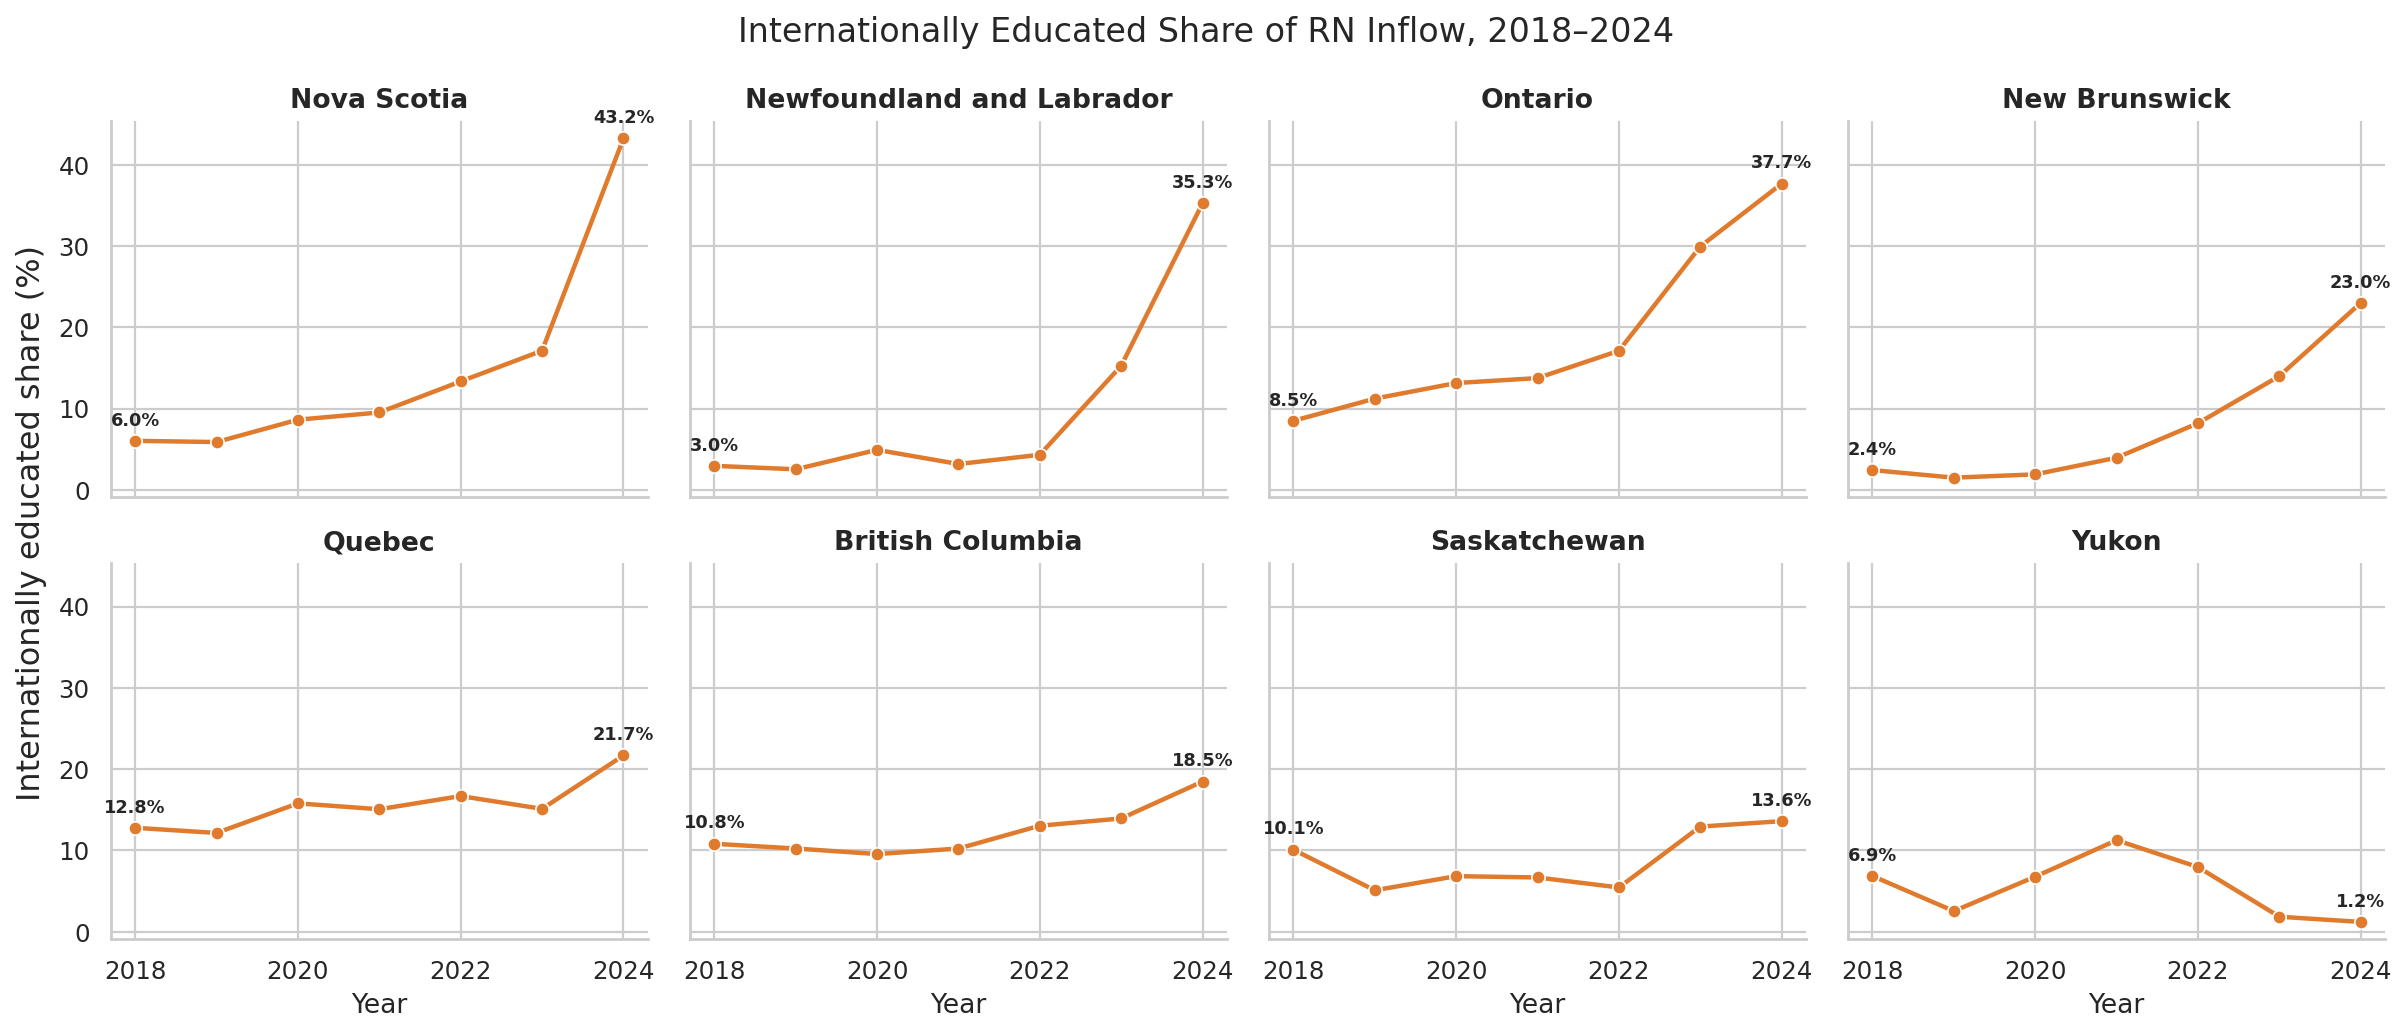

In [8]:
facet = sns.FacetGrid(
    plot_df,
    col="jurisdiction",
    col_wrap=4,
    col_order=share_change.index.tolist(),
    height=3.3,
    aspect=1.15,
    sharey=True,
)
facet.map_dataframe(
    sns.lineplot,
    x="year",
    y="intl_share_pct",
    marker="o",
    color="#E07A2D",
    linewidth=2,
)


def annotate_endpoints(data: pd.DataFrame, **_: object) -> None:
    """Label 2018 and 2024 values in each facet."""
    axis = plt.gca()
    for year in (2018, 2024):
        endpoint = data.loc[data["year"].eq(year), "intl_share_pct"]
        if not endpoint.empty:
            value = float(endpoint.iloc[0])
            axis.annotate(
                f"{value:.1f}%",
                (year, value),
                xytext=(0, 7),
                textcoords="offset points",
                ha="center",
                fontsize=8,
                fontweight="bold",
            )


facet.map_dataframe(annotate_endpoints)
facet.set_titles("{col_name}", fontweight="bold")
facet.set_axis_labels("Year", "")
facet.set(xticks=[2018, 2020, 2022, 2024])
facet.figure.subplots_adjust(top=0.88)
facet.figure.supylabel("Internationally educated share (%)", x=0.01)
facet.figure.suptitle(
    "Internationally Educated Share of RN Inflow, 2018–2024", fontsize=15
)
save_figure(facet.figure, "figure_3_international_share_trends.png")
plt.show()


**Interpretation.** The internationally educated share increased from 2018 to 2024 in seven of eight jurisdictions. The largest increases occurred in Nova Scotia (+37.21 percentage points), Newfoundland and Labrador (+32.30), and Ontario (+29.17). Yukon was the only jurisdiction to decline (−5.65 percentage points).


## 5. Reproduce the principal findings

The final code cell derives the headline results directly from the validated summary tables.


In [9]:
increases = int((share_change["change (percentage points)"] > 0).sum())
decreases = int((share_change["change (percentage points)"] < 0).sum())
largest_increases = share_change.head(3)["change (percentage points)"]
above_break_even = growth_summary.index[
    growth_summary["inflow_per_1k"] > growth_summary["outflow_churn_per_1k"]
].tolist()

print("\nKEY FINDINGS")
print(
    f"1. Average inflow intensity exceeded preceding-year outflow churn in "
    f"{len(above_break_even)} of {len(full_sets)} complete-series jurisdictions."
)
print(
    f"2. The internationally educated share rose in {increases} of "
    f"{len(full_sets)} jurisdictions and fell in {decreases}."
)
print("3. Largest increases in internationally educated share:")
for jurisdiction, change in largest_increases.items():
    print(f"   - {jurisdiction}: {change:+.2f} percentage points")

print("\nLIMITATIONS")
print(
    "The complete-series comparisons exclude Manitoba (missing 2019–2024 data) "
    "and Alberta (missing 2024 data). The analysis is descriptive: it does not "
    "identify causal effects, and outflow should not be interpreted specifically "
    "as retirement. The decomposition discrepancy is retained because the simple "
    "inflow/outflow identity may not capture every source-data adjustment or "
    "workforce movement."
)

print("\nCONCLUSION")
print(
    "Internationally educated nurses represented a growing share of RN inflow "
    "in most complete-series jurisdictions, indicating an increasing role for "
    "international recruitment in workforce growth."
)



KEY FINDINGS
1. Average inflow intensity exceeded preceding-year outflow churn in 7 of 8 complete-series jurisdictions.
2. The internationally educated share rose in 7 of 8 jurisdictions and fell in 1.
3. Largest increases in internationally educated share:
   - Nova Scotia: +37.21 percentage points
   - Newfoundland and Labrador: +32.30 percentage points
   - Ontario: +29.17 percentage points

LIMITATIONS
The complete-series comparisons exclude Manitoba (missing 2019–2024 data) and Alberta (missing 2024 data). The analysis is descriptive: it does not identify causal effects, and outflow should not be interpreted specifically as retirement. The decomposition discrepancy is retained because the simple inflow/outflow identity may not capture every source-data adjustment or workforce movement.

CONCLUSION
Internationally educated nurses represented a growing share of RN inflow in most complete-series jurisdictions, indicating an increasing role for international recruitment in workforce 

## Conclusion

Internationally educated nurses represented a growing share of RN inflow in most complete-series jurisdictions, indicating an increasing role for international recruitment in workforce growth. The pattern was not uniform: the size and timing of the change differed considerably across jurisdictions, and New Brunswick's average inflow remained slightly below its preceding-year outflow.

## Limitations

- Complete-series comparisons exclude Manitoba because 2019–2024 observations are unavailable and Alberta because 2024 is unavailable.
- Prince Edward Island and Northwest Territories/Nunavut also fail the strict completeness requirements used for the figures.
- This is a descriptive analysis and does not identify causal effects.
- CIHI outflow should not be interpreted specifically as retirement.
- The simplified inflow/outflow framework may not capture every source-data revision or workforce movement, which is why the decomposition discrepancy is validated rather than assumed away.
